# CellDataset with Cellpose 2.0 Integration for Chromocenter Detection

This enhanced dataset uses Cellpose 2.0 to automatically detect nuclei and identify chromocenters
based on intensity analysis within the detected nuclei.

## Key Features

1. **Automatic nucleus detection** using Cellpose 2.0
2. **Intensity-based chromocenter detection** within nuclei
3. **Two modes**:
   - `mask_source='cellpose'`: Fully automated (Cellpose + intensity)
   - `mask_source='hybrid'`: Cellpose nuclei + expert chromocenter annotations
   - `mask_source='ground_truth'`: Use original mask files (for comparison)

## Configurable Options

- `mask_source`: 'cellpose', 'hybrid', or 'ground_truth'
- `chromocenter_percentile`: Intensity threshold for detecting chromocenters (default: 85)
- `preprocess_mode`: 'basic' or 'full'
- `aug_strength`: 'none', 'light', or 'standard'
- `cellpose_diameter`: Nucleus diameter for Cellpose (None = auto-detect)

## Output Format

The dataset returns:
- image: FloatTensor (1, H, W) normalized to [0,1]
- mask: LongTensor (H, W) with labels {0,1,2}
  - 0: Background
  - 1: Nucleoplasm
  - 2: Chromocenters

Compatible with `torch.nn.CrossEntropyLoss()`

In [3]:
# Install dependencies
!pip -q install cellpose==2.0 tifffile opencv-python-headless albumentations tifffile


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\js_ba\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [4]:
# Setup for local GPU with Google Drive data
import torch

# Verify GPU is available
print(f"GPU Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
else:
    print("WARNING: GPU not detected.")

# IMPORTANT: Download the CMPUT469_Cell folder from Google Drive manually
# and place it at the path below
root = r'C:\Users\js_ba\Downloads\CMPUT469_Cell'

# Verify the data folder exists
import os
if os.path.exists(root):
    print(f"✓ Data folder found: {root}")
else:
    print(f"✗ ERROR: Data folder not found at {root}")
    print("Please download CMPUT469_Cell from Google Drive and place it in the path above.")

GPU Available: True
GPU Name: NVIDIA GeForce RTX 3050 Laptop GPU
✓ Data folder found: C:\Users\js_ba\Downloads\CMPUT469_Cell


In [5]:
import os, re
import numpy as np
import cv2
import tifffile as tiff
import albumentations as A
import torch
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from cellpose import models
from skimage.transform import resize

In [6]:
class CellDatasetWithCellpose(Dataset):
    """
    PyTorch Dataset for microscopy cell segmentation with Cellpose integration.

    Args:
        root_dir: Project root containing `Microscopy_images` and mask folders
        mask_source: 'cellpose' | 'hybrid' | 'ground_truth'
            - 'cellpose': Fully automated (Cellpose nuclei + intensity-based chromocenters)
            - 'hybrid': Cellpose nuclei + expert chromocenter annotations
            - 'ground_truth': Use original mask files (for comparison)
        chromocenter_percentile: Intensity threshold percentile for chromocenter detection (default: 85)
        preprocess_mode: 'basic' | 'full'
        aug_strength: 'none' | 'light' | 'standard'
        target_size: (H,W) resize target for network (default 256x256)
        cellpose_diameter: Expected nucleus diameter in pixels (None = auto)
        cellpose_model_type: 'nuclei' | 'cyto' | 'cyto2'
        use_gpu: Whether to use GPU for Cellpose (default: True)
        split_ids: Optional list of Cell id strings to include
        cache_cellpose: Cache Cellpose predictions to speed up training (default: True)

    Returns:
        image: FloatTensor (1,H,W) in [0,1]
        mask: LongTensor (H,W) values in {0,1,2}
    """
    def __init__(self,
                 root_dir,
                 mask_source='cellpose',
                 chromocenter_percentile=85,
                 preprocess_mode='basic',
                 aug_strength='standard',
                 target_size=(256,256),
                 cellpose_diameter=None,
                 cellpose_model_type='nuclei',
                 use_gpu=True,
                 split_ids=None,
                 cache_cellpose=True):

        self.root_dir = root_dir
        self.img_dir = os.path.join(root_dir, 'Microscopy_images')

        # Handle mask folder name variations
        alt1 = os.path.join(root_dir, 'Ground_truth_masks')
        alt2 = os.path.join(root_dir, 'Groud_truth_masks')
        self.mask_dir = alt1 if os.path.exists(alt1) else alt2

        self.mask_source = mask_source
        self.chromocenter_percentile = chromocenter_percentile
        self.preprocess_mode = preprocess_mode
        self.aug_strength = aug_strength
        self.target_size = target_size
        self.cellpose_diameter = cellpose_diameter
        self.cache_cellpose = cache_cellpose

        # Initialize Cellpose if needed
        self.cellpose_model = None
        if mask_source in ['cellpose', 'hybrid']:
            print(f"Initializing Cellpose model (type: {cellpose_model_type}, GPU: {use_gpu})...")
            self.cellpose_model = models.Cellpose(gpu=use_gpu, model_type=cellpose_model_type)
            print("Cellpose model loaded successfully")

        # Cache for Cellpose predictions
        self.cellpose_cache = {}

        # Build augmentation pipeline
        self.aug = self._make_augmentation(aug_strength)

        # Discover samples
        self.samples = self._find_samples(split_ids)

        # Pre-run Cellpose on all images if caching is enabled
        if self.cache_cellpose and self.cellpose_model is not None:
            print(f"Pre-computing Cellpose predictions for {len(self.samples)} images...")
            self._precompute_cellpose()
            print("Cellpose pre-computation complete")

    def _find_samples(self, split_ids=None):
        """Find all valid image-mask pairs."""
        pattern = re.compile(r'Microscope_image_Cell(\d+)\.tif')
        split_ids = set(split_ids) if split_ids else None
        ids = []

        for f in sorted(os.listdir(self.img_dir)):
            m = pattern.match(f)
            if not m:
                continue
            cid = m.group(1)

            # Check if required files exist based on mask_source
            img_path = os.path.join(self.img_dir, f'Microscope_image_Cell{cid}.tif')

            if self.mask_source == 'ground_truth':
                nuc = os.path.join(self.mask_dir, f'Nucleus_mask_Cell{cid}.tif')
                chrm = os.path.join(self.mask_dir, f'Chromocenter_mask_Cell{cid}.tif')
                if os.path.exists(nuc) and os.path.exists(chrm):
                    if split_ids is None or cid in split_ids:
                        ids.append(cid)
            elif self.mask_source == 'hybrid':
                chrm = os.path.join(self.mask_dir, f'Chromocenter_mask_Cell{cid}.tif')
                if os.path.exists(img_path) and os.path.exists(chrm):
                    if split_ids is None or cid in split_ids:
                        ids.append(cid)
            else:  # cellpose
                if os.path.exists(img_path):
                    if split_ids is None or cid in split_ids:
                        ids.append(cid)

        return ids

    def _make_augmentation(self, strength):
        """Build augmentation pipeline."""
        transforms = []

        if strength == 'none' or strength is None:
            pass
        elif strength == 'light':
            transforms.extend([
                A.HorizontalFlip(p=0.5),
                A.VerticalFlip(p=0.5),
                A.RandomRotate90(p=0.5),
            ])
        elif strength == 'standard':
            transforms.extend([
                A.HorizontalFlip(p=0.5),
                A.VerticalFlip(p=0.5),
                A.RandomRotate90(p=0.5),
                A.Affine(
                    translate_percent={'x': (-0.1, 0.1), 'y': (-0.1, 0.1)},
                    scale=(0.85, 1.15),
                    rotate=(-45, 45),
                    border_mode=cv2.BORDER_REFLECT,
                    p=0.5,
                ),
                A.ElasticTransform(alpha=120, sigma=120 * 0.05, p=0.3),
                A.RandomBrightnessContrast(
                    brightness_limit=0.15,
                    contrast_limit=0.15,
                    p=0.3
                ),
            ])
        else:
            raise ValueError(f"Unknown augmentation strength: {strength}")

        # Always resize last
        if self.target_size is not None:
            transforms.append(
                A.Resize(
                    height=self.target_size[0],
                    width=self.target_size[1],
                    interpolation=cv2.INTER_LINEAR,
                    mask_interpolation=cv2.INTER_NEAREST
                )
            )

        return A.Compose(transforms)

    def _preprocess_image(self, img_u16):
        """Preprocess microscopy image."""
        img = img_u16.astype(np.float32)
        lo, hi = np.percentile(img, 1), np.percentile(img, 99.5)
        img = np.clip(img, lo, hi)
        img01 = (img - lo) / (hi - lo + 1e-8)

        if self.preprocess_mode == 'basic':
            result = img01
        elif self.preprocess_mode == 'full':
            img01 = cv2.bilateralFilter(img01, d=5, sigmaColor=0.08, sigmaSpace=3)
            k = 51
            if k % 2 == 0: k += 1
            k = max(k, 15)
            bg = cv2.GaussianBlur(img01, (k, k), 0)
            corr = img01 - bg
            lo2, hi2 = np.percentile(corr, 1), np.percentile(corr, 99.5)
            corr = np.clip(corr, lo2, hi2)
            result = (corr - lo2) / (hi2 - lo2 + 1e-8)
        else:
            raise ValueError('Unknown preprocess mode')

        return result.astype(np.float32)

    def _run_cellpose(self, img_raw):
        """Run Cellpose on raw microscopy image."""
        # Normalize to 8-bit for Cellpose
        if img_raw.dtype != np.uint8:
            img_normalized = ((img_raw - img_raw.min()) / (img_raw.max() - img_raw.min()) * 255).astype(np.uint8)
        else:
            img_normalized = img_raw

        # Run Cellpose
        masks, flows, styles, diams = self.cellpose_model.eval(
            img_normalized,
            diameter=self.cellpose_diameter,
            channels=[[0, 0]],  # Grayscale
            flow_threshold=0.4,
            cellprob_threshold=0.0
        )

        return masks

    def _precompute_cellpose(self):
        """Pre-compute Cellpose predictions for all images."""
        from tqdm import tqdm

        for cid in tqdm(self.samples, desc="Computing Cellpose masks"):
            img_path = os.path.join(self.img_dir, f'Microscope_image_Cell{cid}.tif')
            img_raw = tiff.imread(img_path)
            cellpose_mask = self._run_cellpose(img_raw)
            self.cellpose_cache[cid] = cellpose_mask

    def _detect_chromocenters_intensity(self, img_raw, nucleus_mask):
        """Detect chromocenters using intensity thresholding within nuclei."""
        chromocenter_mask = np.zeros_like(nucleus_mask, dtype=np.uint8)

        # Binary nucleus mask
        nuclei = nucleus_mask > 0

        if np.any(nuclei):
            # Get intensities within nuclei
            nuclei_intensities = img_raw[nuclei]

            # Calculate threshold
            intensity_threshold = np.percentile(nuclei_intensities, self.chromocenter_percentile)

            # Mark high-intensity regions as chromocenters
            chromocenters = nuclei & (img_raw >= intensity_threshold)
            chromocenter_mask[chromocenters] = 1

        return chromocenter_mask

    def _build_mask_cellpose(self, img_raw, cid):
        """Build 3-class mask using Cellpose nucleus detection + intensity-based chromocenter detection."""
        # Get Cellpose nucleus mask (from cache or compute)
        if self.cache_cellpose and cid in self.cellpose_cache:
            cellpose_mask = self.cellpose_cache[cid]
        else:
            cellpose_mask = self._run_cellpose(img_raw)
            if self.cache_cellpose:
                self.cellpose_cache[cid] = cellpose_mask

        # Detect chromocenters using intensity
        chromocenter_mask = self._detect_chromocenters_intensity(img_raw, cellpose_mask)

        # Build 3-class mask
        mask = np.zeros_like(cellpose_mask, dtype=np.uint8)

        # Class 0: Background (where no nucleus detected)
        background = cellpose_mask == 0
        mask[background] = 0

        # Class 2: Chromocenters
        chromocenters = chromocenter_mask == 1
        mask[chromocenters] = 2

        # Class 1: Nucleoplasm (nucleus but not chromocenter)
        nuclei = cellpose_mask > 0
        nucleoplasm = nuclei & (~chromocenters)
        mask[nucleoplasm] = 1

        return mask

    def _build_mask_hybrid(self, img_raw, cid):
        """Build 3-class mask using Cellpose nuclei + expert chromocenter annotations."""
        # Get Cellpose nucleus mask
        if self.cache_cellpose and cid in self.cellpose_cache:
            cellpose_mask = self.cellpose_cache[cid]
        else:
            cellpose_mask = self._run_cellpose(img_raw)
            if self.cache_cellpose:
                self.cellpose_cache[cid] = cellpose_mask

        # Load expert chromocenter annotations
        chrm_path = os.path.join(self.mask_dir, f'Chromocenter_mask_Cell{cid}.tif')
        chrm_raw = tiff.imread(chrm_path)

        # Normalize chromocenter mask (0=not-chromo, 255=chromo -> 0=not-chromo, 1=chromo)
        chromocenter_mask = (chrm_raw == 255).astype(np.uint8)

        # Build 3-class mask
        mask = np.zeros_like(cellpose_mask, dtype=np.uint8)

        # Class 0: Background
        background = cellpose_mask == 0
        mask[background] = 0

        # Class 2: Chromocenters (from experts)
        chromocenters = chromocenter_mask == 1
        mask[chromocenters] = 2

        # Class 1: Nucleoplasm
        nuclei = cellpose_mask > 0
        nucleoplasm = nuclei & (~chromocenters)
        mask[nucleoplasm] = 1

        return mask

    def _build_mask_ground_truth(self, cid):
        """Build 3-class mask from original ground truth files."""
        nuc = tiff.imread(os.path.join(self.mask_dir, f'Nucleus_mask_Cell{cid}.tif'))
        chrom = tiff.imread(os.path.join(self.mask_dir, f'Chromocenter_mask_Cell{cid}.tif'))

        # Original logic: 0 in mask = foreground
        nuc_fg = (nuc == 0).astype(np.uint8)
        chrom_fg = (chrom == 0).astype(np.uint8)

        mask = np.zeros_like(nuc_fg, dtype=np.uint8)
        mask[nuc_fg == 1] = 1
        mask[chrom_fg == 1] = 2

        return mask

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        cid = self.samples[idx]

        # Load raw image
        img_path = os.path.join(self.img_dir, f'Microscope_image_Cell{cid}.tif')
        img_raw = tiff.imread(img_path)

        # Build mask based on source
        if self.mask_source == 'cellpose':
            mask = self._build_mask_cellpose(img_raw, cid)
        elif self.mask_source == 'hybrid':
            mask = self._build_mask_hybrid(img_raw, cid)
        else:  # ground_truth
            mask = self._build_mask_ground_truth(cid)

        # Preprocess image for network
        img_pp = self._preprocess_image(img_raw)

        # Apply augmentations
        if self.aug is not None:
            augmented = self.aug(image=img_pp, mask=mask)
            img_pp, mask = augmented['image'], augmented['mask']

        # Convert to tensors
        img_t = torch.from_numpy(img_pp).unsqueeze(0).float()
        mask_t = torch.from_numpy(mask.astype(np.int64))

        return img_t, mask_t

# Example Usage

## Example 1: Fully Automated with Cellpose

In [7]:
ROOT = r'C:\Users\js_ba\Downloads\CMPUT469_Cell'

# Fully automated: Cellpose nuclei + intensity-based chromocenters
ds_cellpose = CellDatasetWithCellpose(
    ROOT,
    mask_source='cellpose',           # Fully automated
    chromocenter_percentile=85,       # Top 15% intensity = chromocenters
    preprocess_mode='basic',
    aug_strength='standard',
    target_size=(256, 256),
    cellpose_diameter=None,           # Auto-detect
    use_gpu=True,
    cache_cellpose=True               # Cache predictions for speed
)

loader = DataLoader(ds_cellpose, batch_size=4, shuffle=True)
images, masks = next(iter(loader))

print('images', images.shape, images.dtype, images.min(), images.max())
print('masks', masks.shape, masks.dtype, torch.unique(masks))

Initializing Cellpose model (type: nuclei, GPU: True)...


C:\Users\js_ba\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\cellpose\resnet_torch.py:222: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issue

Cellpose model loaded successfully
Pre-computing Cellpose predictions for 200 images...


Computing Cellpose masks:   6%|▌         | 11/200 [00:06<01:36,  1.95it/s]C:\Users\js_ba\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\js_ba\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
Computing Cellpose masks: 100%|██████████| 200/200 [01:32<00:00,  2.16it/s]

Cellpose pre-computation complete
images torch.Size([4, 1, 256, 256]) torch.float32 tensor(0.) tensor(1.)
masks torch.Size([4, 256, 256]) torch.int64 tensor([0, 1, 2])


In [8]:
import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from cellpose import models
import warnings

warnings.filterwarnings('ignore')

In [12]:
import random

ROOT = r'C:\Users\js_ba\Downloads\CMPUT469_Cell'

# 1. Initialize dataset to get all sample IDs
all_ds = CellDatasetWithCellpose(ROOT, mask_source='ground_truth', aug_strength='none')
all_ids = all_ds.samples # Assuming this is a list of strings/IDs

# 2. Define your specific Test set (the 40 cells provided)
test_ids = [
    '02', '07', '08', '09', '108', '109', '115', '130', '140', '144', 
    '151', '152', '155', '164', '167', '169', '174', '182', '186', '189', 
    '190', '192', '198', '23', '24', '27', '29', '36', '40', '41', 
    '51', '56', '57', '58', '60', '63', '71', '72', '87', '88'
]

# 3. Create the Training set by removing the test_ids from all_ids
train_ids = [id for id in all_ids if id not in test_ids]

# Verification
print(f"Total Samples found in directory: {len(all_ids)}")
print(f"Fixed Split -> Train: {len(train_ids)} images, Test: {len(test_ids)} images")

# Safety check to ensure exactly 160/40 split
if len(train_ids) != 160 or len(test_ids) != 40:
    print(f"Warning: Split is {len(train_ids)}/{len(test_ids)}. Check if all IDs exist in ROOT.")

Total Samples found in directory: 200
Fixed Split -> Train: 160 images, Test: 40 images


In [13]:
# 1. Create Dataset Objects using the 160/40 Split
# Training datasets (160 images)
ds_train_no_aug = CellDatasetWithCellpose(ROOT, split_ids=train_ids, mask_source='ground_truth', aug_strength='none', use_gpu=True)
ds_train_aug = CellDatasetWithCellpose(ROOT, split_ids=train_ids, mask_source='ground_truth', aug_strength='standard', use_gpu=True)

# Testing dataset (40 images)
ds_test = CellDatasetWithCellpose(ROOT, split_ids=test_ids, mask_source='ground_truth', aug_strength='none', use_gpu=True)

def extract_instances_for_cellpose(dataset):
    """Converts semantic masks (Class 2) into instance masks for Cellpose training"""
    imgs, instance_masks = [], []
    for i in range(len(dataset)):
        img_t, mask_t = dataset[i]

        # Format Image for Cellpose (0-255 uint8)
        img_np = img_t.squeeze().numpy()
        img_uint8 = (img_np * 255).astype(np.uint8)

        # Isolate Chromocenters (Class 2) and create unique instances
        # This is critical: Cellpose needs individual objects to have unique IDs (1, 2, 3...)
        chromo_binary = (mask_t.squeeze().numpy() == 2).astype(np.uint8)
        num_labels, instances = cv2.connectedComponents(chromo_binary)

        imgs.append(img_uint8)
        instance_masks.append(instances)
    return imgs, instance_masks



print("Preparing data for Cellpose...")
# Extracting 160 Training samples (Non-Augmented)
train_imgs_na, train_masks_na = extract_instances_for_cellpose(ds_train_no_aug)

# Extracting 160 Training samples (Augmented)
train_imgs_a, train_masks_a = extract_instances_for_cellpose(ds_train_aug)

# Extracting 40 Testing samples
test_imgs, test_masks = extract_instances_for_cellpose(ds_test)

print(f"Extraction Complete:")
print(f"Training sets: {len(train_imgs_na)} images each")
print(f"Testing set: {len(test_imgs)} images")

Preparing data for Cellpose...
Extraction Complete:
Training sets: 160 images each
Testing set: 40 images


In [14]:
# Initialize three separate models to avoid weight bleeding
print("Initializing models...")
# model_orig is our pre-trained baseline; we do NOT train it.
model_orig = models.CellposeModel(gpu=True, model_type='nuclei') 

model_no_aug = models.CellposeModel(gpu=True, model_type='nuclei')
model_aug = models.CellposeModel(gpu=True, model_type='nuclei')

# Train Model 1: Non-Augmented (160 training images)
print("\n--- Training Model: Non-Augmented ---")
path_no_aug = model_no_aug.train(
    train_imgs_na, 
    train_masks_na,
    test_data=test_imgs,    # Monitor progress on the 40 test cells
    test_labels=test_masks, 
    channels=[0,0], 
    save_path=ROOT, 
    n_epochs=50,
    model_name='cp_chromo_no_aug'
)

# Train Model 2: Augmented (160 training images)
print("\n--- Training Model: Augmented ---")
path_aug = model_aug.train(
    train_imgs_a, 
    train_masks_a,
    test_data=test_imgs,    # Monitor progress on the 40 test cells
    test_labels=test_masks, 
    channels=[0,0], 
    save_path=ROOT, 
    n_epochs=50,
    model_name='cp_chromo_aug'
)

Initializing models...

--- Training Model: Non-Augmented ---


100%|██████████| 40/40 [00:01<00:00, 36.95it/s]



--- Training Model: Augmented ---


100%|██████████| 40/40 [00:00<00:00, 40.14it/s]


In [ ]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt


def calc_metrics(pred_instances, gt_instances):
    pred_bin = (pred_instances > 0).astype(np.uint8)
    gt_bin = (gt_instances > 0).astype(np.uint8)
    intersection = np.logical_and(pred_bin, gt_bin).sum()
    union = np.logical_or(pred_bin, gt_bin).sum()
    iou = intersection / union if union > 0 else 0
    total_pixels = pred_bin.sum() + gt_bin.sum()
    dice = (2 * intersection) / total_pixels if total_pixels > 0 else 0
    
    return iou, dice

ranked_data = []

print(f"Evaluating {len(test_imgs)} test images...")
for i in range(len(test_imgs)):
    img = test_imgs[i]
    gt = test_masks[i]
    img_id = test_ids[i]

    p_orig, _, _ = model_orig.eval(img, diameter=None, channels=[0,0])
    p_na, _, _ = model_no_aug.eval(img, diameter=None, channels=[0,0])
    p_a, _, _ = model_aug.eval(img, diameter=None, channels=[0,0])

    iou_a, d_a = calc_metrics(p_a, gt)
    iou_na, d_na = calc_metrics(p_na, gt)
    iou_o, d_o = calc_metrics(p_orig, gt)

    ranked_data.append({
        'id': img_id, 
        'img': img, 
        'gt': gt,
        'p_orig': p_orig, 'd_o': d_o, 'iou_o': iou_o,
        'p_na': p_na, 'd_na': d_na, 'iou_na': iou_na,
        'p_a': p_a, 'd_a': d_a, 'iou_a': iou_a
    })

ranked_data.sort(key=lambda x: x['d_a'], reverse=True)

csv_results = []
for res in ranked_data:
    csv_results.append({
        'Image_ID': res['id'],
        'Dice_Augmented': round(res['d_a'], 4),
        'IoU_Augmented': round(res['iou_a'], 4),
        'Dice_No_Aug': round(res['d_na'], 4),
        'Dice_Pretrained': round(res['d_o'], 4)
    })

df = pd.DataFrame(csv_results)
csv_path = os.path.join(ROOT, 'test_performance_ranked.csv')
df.to_csv(csv_path, index=False)
print(f"Results exported to: {csv_path}")

save_dir = os.path.join(ROOT, "ranked_visualizations")
os.makedirs(save_dir, exist_ok=True)

cols = ['Test Image', 'Ground Truth', 'Original (Pre-trained)', 
        'Trained (No Aug)', 'Trained (Augmented)']

for i, res in enumerate(ranked_data):

    fig, axes = plt.subplots(1, 5, figsize=(18,4))

    for ax, col in zip(axes, cols):
        ax.set_title(col, fontweight='bold', fontsize=12)

    # --- Fix Image Shape ---
    display_img = res['img']
    if len(display_img.shape) == 3:
        display_img = display_img[0]

    # Column 1: Test Image
    axes[0].imshow(display_img, cmap='gray')
    axes[0].set_ylabel(f"ID: {res['id']}\nRank: {i+1}", fontweight='bold')

    # Column 2: Ground Truth
    axes[1].imshow(res['gt'].squeeze() > 0, cmap='gray')

    # Column 3: Pretrained
    axes[2].imshow(res['p_orig'].squeeze() > 0, cmap='gray')
    axes[2].set_xlabel(f"Dice: {res['d_o']:.4f}")

    # Column 4: No Aug
    axes[3].imshow(res['p_na'].squeeze() > 0, cmap='gray')
    axes[3].set_xlabel(f"Dice: {res['d_na']:.4f}")

    # Column 5: Augmented
    axes[4].imshow(res['p_a'].squeeze() > 0, cmap='gray')
    axes[4].set_xlabel(f"Dice: {res['d_a']:.4f}", fontweight='bold')

    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])

    plt.tight_layout()

    # Save figure
    filename = f"rank_{i+1:02d}_ID_{res['id']}.png"
    save_path = os.path.join(save_dir, filename)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()

print(f"Individual ranked visualizations saved to: {save_dir}")

Evaluating 40 test images...
Results exported to: C:\Users\js_ba\Downloads\CMPUT469_Cell\test_performance_ranked.csv
Individual ranked visualizations saved to: C:\Users\js_ba\Downloads\CMPUT469_Cell\ranked_visualizations


Calculating final mean metrics for 40 images...


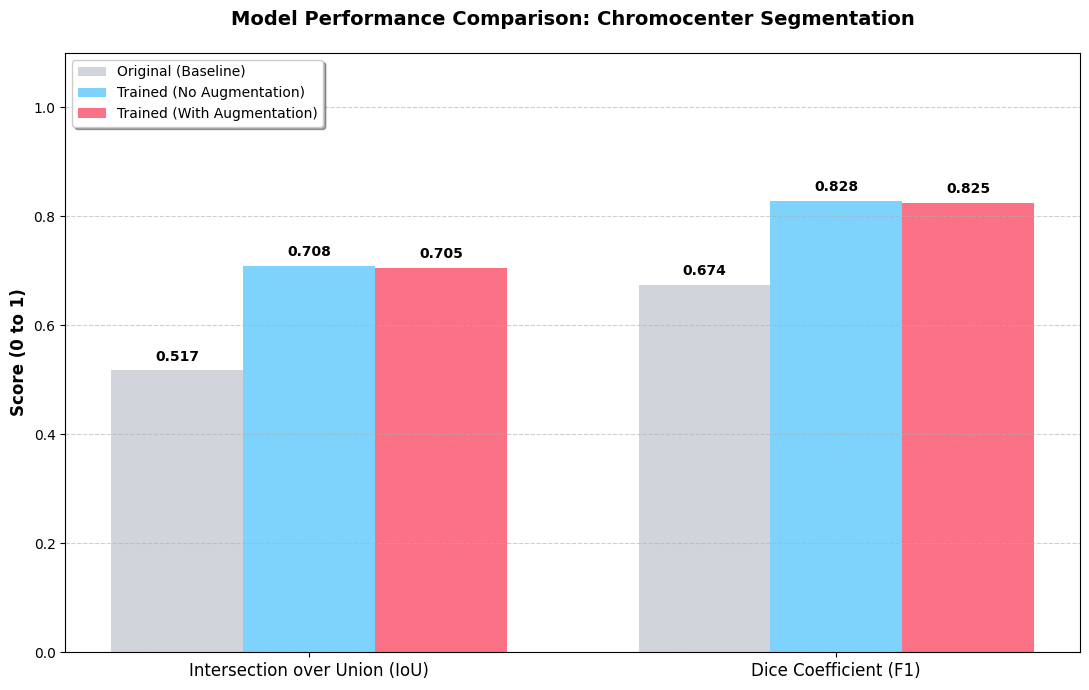

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

summary_stats = {'orig_iou': [], 'orig_dice': [], 'na_iou': [], 'na_dice': [], 'a_iou': [], 'a_dice': []}

print(f"Calculating final mean metrics for {len(test_imgs)} images...")
for i in range(len(test_imgs)):
    img, gt = test_imgs[i], test_masks[i]
    
    p_orig, _, _ = model_orig.eval(img, diameter=None, channels=[0,0])
    p_na, _, _ = model_no_aug.eval(img, diameter=None, channels=[0,0])
    p_a, _, _ = model_aug.eval(img, diameter=None, channels=[0,0])
    
    iou_o, d_o = calc_metrics(p_orig, gt)
    iou_na, d_na = calc_metrics(p_na, gt)
    iou_a, d_a = calc_metrics(p_a, gt)
    
    summary_stats['orig_iou'].append(iou_o); summary_stats['orig_dice'].append(d_o)
    summary_stats['na_iou'].append(iou_na); summary_stats['na_dice'].append(d_na)
    summary_stats['a_iou'].append(iou_a); summary_stats['a_dice'].append(d_a)

labels = ['Intersection over Union (IoU)', 'Dice Coefficient (F1)']
means_orig = [np.mean(summary_stats['orig_iou']), np.mean(summary_stats['orig_dice'])]
means_na = [np.mean(summary_stats['na_iou']), np.mean(summary_stats['na_dice'])]
means_a = [np.mean(summary_stats['a_iou']), np.mean(summary_stats['a_dice'])]

x = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 7))

rects1 = ax.bar(x - width, means_orig, width, label='Original (Baseline)', color='#d1d5db')
rects2 = ax.bar(x, means_na, width, label='Trained (No Augmentation)', color='#7dd3fc')
rects3 = ax.bar(x + width, means_a, width, label='Trained (With Augmentation)', color='#fb7185')

ax.set_ylabel('Score (0 to 1)', fontsize=12, fontweight='bold')
ax.set_title('Model Performance Comparison: Chromocenter Segmentation', fontsize=14, pad=20, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)
ax.legend(loc='upper left', frameon=True, shadow=True)
ax.set_ylim(0, 1.1)
ax.grid(axis='y', linestyle='--', alpha=0.6)

ax.bar_label(rects1, fmt='%.3f', padding=5, fontweight='bold')
ax.bar_label(rects2, fmt='%.3f', padding=5, fontweight='bold')
ax.bar_label(rects3, fmt='%.3f', padding=5, fontweight='bold')

plt.tight_layout()
plt.show()